# Assignment 2.4: Bit-Plane Slicing and Contrast Stretching

### 1. Import Libraries

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### 2. Load Image

In [ ]:
# Path to input image
image_path = "../assets/input/sample.jpg"

# Read image using OpenCV
image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError(f"Could not load image: {image_path}")

# Convert BGR image to grayscale
gray_image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

print("Image shape:", gray_image.shape)
print("Image data type:", gray_image.dtype)

Image shape: (480, 640)
Image data type: uint8


### 3. Display Grayscale Image

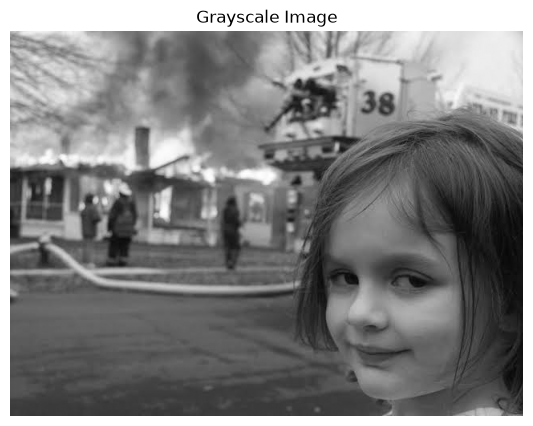

In [ ]:
plt.figure(figsize=(7, 5))

plt.imshow(
    gray_image,
    cmap="gray"
)

plt.title("Grayscale Image")
plt.axis("off")

plt.show()

### 4. Extract All 8 Bit Planes

An 8-bit grayscale pixel contains 8 bits:
```txt
Bit 7  Bit 6  Bit 5  Bit 4  Bit 3  Bit 2  Bit 1  Bit 0
 MSB                                              LSB
```
Use NumPy bit operations to extract each plane.

In [ ]:
# Create an array to store the 8 bit planes
bit_planes = []

for bit in range(8):
    
    # Extract the selected bit
    plane = (gray_image >> bit) & 1
    
    # Convert 0/1 to 0/255 for visualization
    plane = plane * 255
    
    bit_planes.append(plane.astype(np.uint8))

### 5. Display Bit Planes

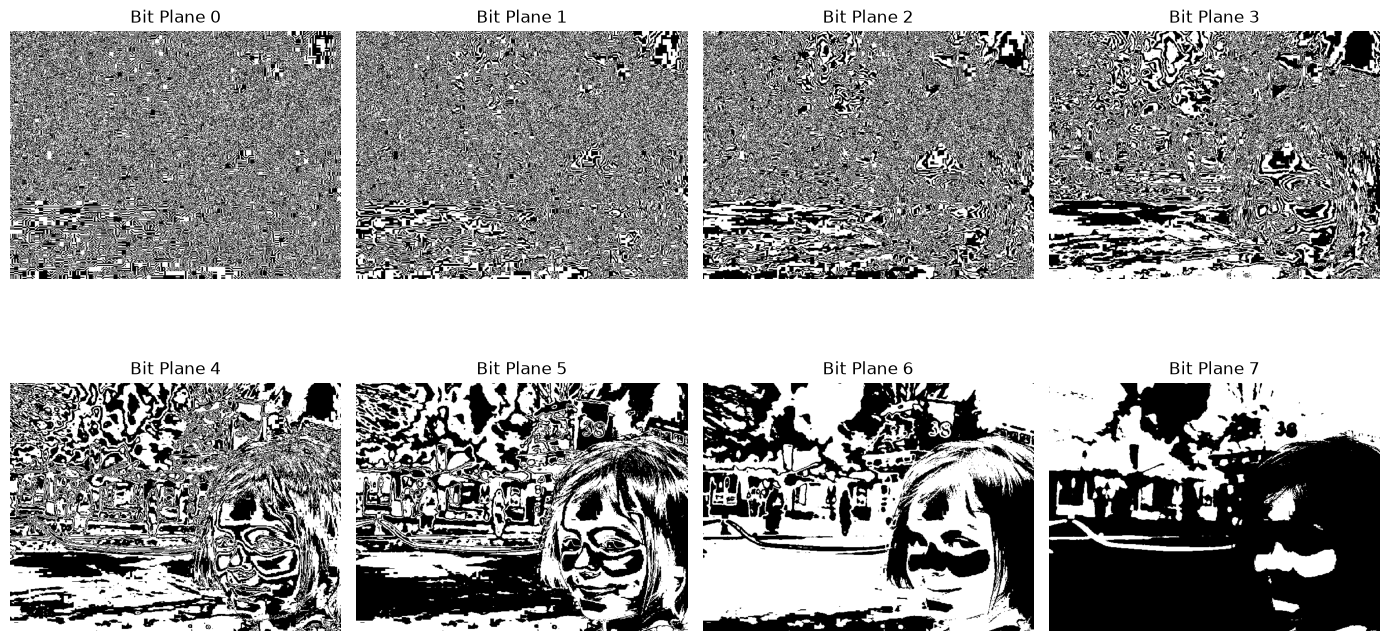

In [ ]:
fig, axes = plt.subplots(
    2,
    4,
    figsize=(14, 8)
)

for bit in range(8):
    
    row = bit // 4
    col = bit % 4
    
    axes[row, col].imshow(
        bit_planes[bit],
        cmap="gray"
    )
    
    axes[row, col].set_title(
        f"Bit Plane {bit}"
    )
    
    axes[row, col].axis("off")

plt.tight_layout()
plt.show()

### 6. Display Bit Planes from MSB to LSB

For image processing, it can be useful to visualize the planes from Bit 7 (MSB) down to Bit 0 (LSB).

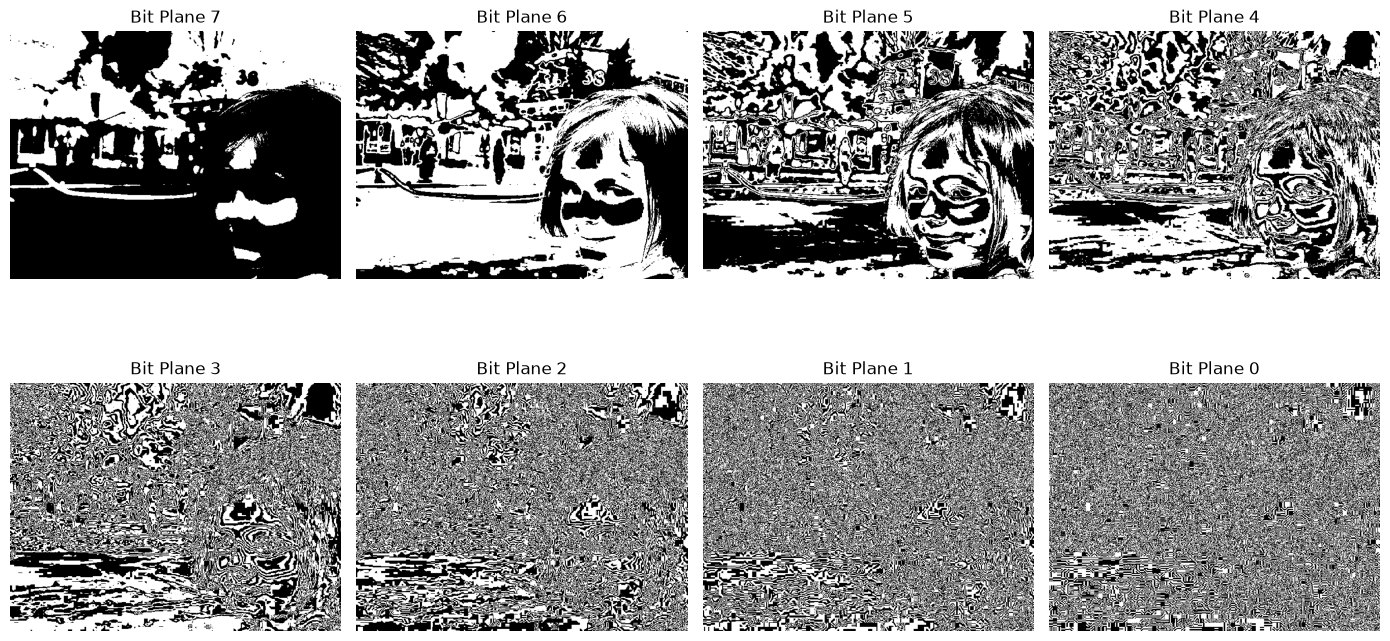

In [ ]:
fig, axes = plt.subplots(
    2,
    4,
    figsize=(14, 8)
)

for index, bit in enumerate(range(7, -1, -1)):
    
    row = index // 4
    col = index % 4
    
    axes[row, col].imshow(
        bit_planes[bit],
        cmap="gray"
    )
    
    axes[row, col].set_title(
        f"Bit Plane {bit}"
    )
    
    axes[row, col].axis("off")

plt.tight_layout()
plt.show()

### 7. Display Individual Important Bit Planes

The higher-order bit planes generally contain more of the major image structure.

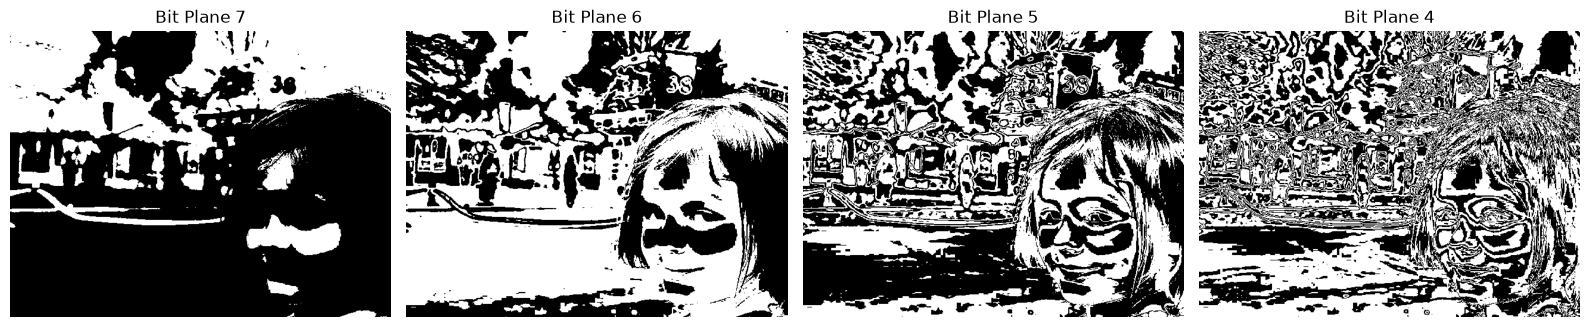

In [ ]:
fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4)
)

for index, bit in enumerate([7, 6, 5, 4]):
    
    axes[index].imshow(
        bit_planes[bit],
        cmap="gray"
    )
    
    axes[index].set_title(
        f"Bit Plane {bit}"
    )
    
    axes[index].axis("off")

plt.tight_layout()
plt.show()